In [1]:
%run /home/mrixen/Case_studies/Clean_code/functions/functions.ipynb

In [2]:
start_era = '2020-02-08T00'
end_era = '2020-02-15T00'
ds_era_geo = load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='H',
)
z500_era = ds_era_geo.Z.sel(plev=50000).sel(lat=slice(20,80), lon = slice(-100,45))  /9.81


In [3]:
ERA5_30D_mean_climatology = xr.open_dataset('/home/mrixen/Case_studies/Clean_code/data/3D_running_mean_era5_Z500_2.nc')['Z'].isel(plev=0).sel(lat=slice(20,80), lon = slice(-100,45))/9.81

## ACC per resolution

In [4]:

# --- Define ensembles and plotting positions --- 
ensembles = {
    "R02B06": 
        { "path": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B06/Ensembles_IC_perturb/Dennis_ensemble_R02B06_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-07T23:30"), 
        "color": "purple" }, 
    "R02B07": 
        { "path": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-07T23:30"), 
         "color": "darkorange" }, 
    "R02B08 conv. off": 
        { "path": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B08_no_conv/Ensembles_IC_perturb/Dennis_ensemble_R02B08_no_conv_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-07T22:30"), 
         "color": "#8da0cb" },
    "R02B08": 
        { "path": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B08/Ensembles_IC_perturb/Dennis_ensemble_R02B08_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-07T22:25"), 
         "color": "forestgreen" }, 
    "R02B09": 
        { "path": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B09/Ensembles_IC_perturb/Dennis_ensemble_R02B09_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-08T00:00"), 
         "color": "mediumblue" },
    "R02B10":
        { "path": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B10/Ensembles_IC_perturb/Dennis_ensemble_R02B10_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-08T01:30"), 
         "color": "firebrick" }
}

In [5]:
names_r02b06, acc_r02b06, rmse_r02b06 = compute_acc_members(
    ensembles["R02B06"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b07, acc_r02b07, rmse_r02b07 = compute_acc_members(
    ensembles["R02B07"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b08, acc_r02b08, rmse_r02b08 = compute_acc_members(
    ensembles["R02B08"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b08_no_conv, acc_r02b08_no_conv, rmse_r02b08_no_conv = compute_acc_members(
    ensembles["R02B08 conv. off"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b09, acc_r02b09, rmse_r02b09 = compute_acc_members(
    ensembles["R02B09"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b10, acc_r02b10, rmse_r02b10 = compute_acc_members(
    ensembles["R02B10"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
!
rmse_dict = {
    "R02B06": rmse_r02b06,
    "R02B07": rmse_r02b07,
    "R02B08": rmse_r02b08,
    "R02B08_no_conv": rmse_r02b08_no_conv,
    "R02B09": rmse_r02b09,
    "R02B10": rmse_r02b10,
}

acc_dict = {
    "R02B06": acc_r02b06,
    "R02B07": acc_r02b07,
    "R02B08": acc_r02b08,
    "R02B08_no_conv": acc_r02b08_no_conv,
    "R02B09": acc_r02b09,
    "R02B10": acc_r02b10,
}

In [6]:
ds_IFS_ens = xr.open_dataset("/highres_nobackup/mrixen/ifs_ens/MARS/MARS_request_ens/eps_20200208_00.nc")
ds_IFS_ens = ds_IFS_ens.rename({'latitude': 'lat', 'longitude': 'lon'})
ds_IFS_ens = ds_IFS_ens.sel(lat=ds_IFS_ens.lat[::-1])

z500_ifs_ens = ds_IFS_ens.z.sel(level=500).sel(lat=slice(20,80), lon = slice(-100,45)).sel(time=slice("2020-02-08T00","2020-02-20T00")) /9.81
acc_ifs_ens, rmse_ifs_ens = compute_acc_rmse(z500_ifs_ens, z500_era, ERA5_30D_mean_climatology)
acc_ifs_ens = acc_ifs_ens.sel(time='2020-02-14T12:00:00.000000000')

ds_IFS = xr.open_dataset('/highres_nobackup/michaesp/eps.ecmwf/cfc_20200208_00.nc')
ds_IFS = ds_IFS.rename({'latitude': 'lat', 'longitude': 'lon'})
ds_IFS = ds_IFS.sel(lat=ds_IFS.lat[::-1])
z500_ifs = ds_IFS.z.sel(level=500).sel(lat=slice(20,80), lon = slice(-100,45)).sel(time=slice("2020-02-08T00","2020-02-20T00")) /9.81
acc_ifs, rmse_ifs = compute_acc_rmse(z500_ifs, z500_era, ERA5_30D_mean_climatology)
acc_ifs = acc_ifs.sel(time='2020-02-14T12:00:00.000000000')

In [7]:
# --- Your datasets ---
datasets = {
    "IFS": {"names": names_r02b06, "acc": acc_ifs_ens.values, "color": "black", "marker": "x"},
    "40 km": {"names": names_r02b06, "acc": acc_r02b06, "color": "purple", "marker": "o"},
    "20 km": {"names": names_r02b07, "acc": acc_r02b07, "color": "darkorange", "marker": "o"},
    "10 km": {"names": names_r02b08, "acc": acc_r02b08, "color": "forestgreen", "marker": "o"},
    "10 km\nconv. off": {"names": names_r02b08_no_conv, "acc": acc_r02b08_no_conv, "color": "#8da0cb", "marker": "o"},
    "5 km": {"names": names_r02b09, "acc": acc_r02b09, "color": "mediumblue", "marker": "o"},
    "2.5 km": {"names": names_r02b10, "acc": acc_r02b10, "color": "firebrick", "marker": "o"},
}

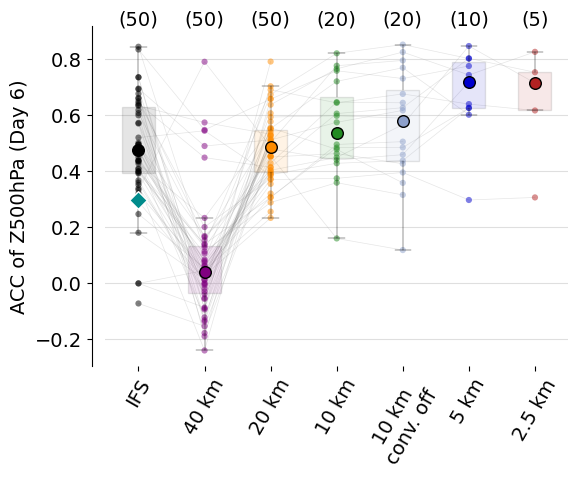

In [8]:
# Prepare single panel
fig, ax2 = plt.subplots(
    1, 1,
    figsize=(6, 5),
    subplot_kw=None
)

dataset_names = list(datasets.keys())

# --- Collect ensemble IDs for optional linking ---
ensemble_ids = sorted({
    int(re.search(r"_IC_(\d{3})_", f).group(1))
    for cfg in datasets.values()
    for f in cfg["names"]
})


# ======================================================
# RIGHT PANEL — Mean ACC + scatter + boxplots
# ======================================================

# --- 1️⃣ Scatter points per dataset ---
for i, (name, cfg) in enumerate(datasets.items()):
    acc = np.array(cfg["acc"])
    acc = acc[np.isfinite(acc)]
    if len(acc) == 0:
        continue

    ax2.scatter(
        np.full(len(acc), i), acc,
        color=cfg["color"],
        s=20,
        alpha=0.5,
        edgecolor="none",
        zorder=2
    )

for ens_id in ensemble_ids:
    x_vals, y_vals = [], []
    for i, (name, cfg) in enumerate(datasets.items()):
        idx = [j for j, f in enumerate(cfg["names"]) if f"_IC_{ens_id:03d}_" in f]
        if len(idx) == 1:
            acc_val = cfg["acc"][idx[0]]
            if np.isfinite(acc_val):
                x_vals.append(i)
                y_vals.append(acc_val)

    if len(x_vals) >= 2:
        ax2.plot(x_vals, y_vals, color="gray", alpha=0.2, linewidth=0.5, zorder=1)


# --- 2️⃣ Boxplots underneath scatter points ---
box_data = [
    np.array(cfg["acc"])[np.isfinite(cfg["acc"])]
    for cfg in datasets.values()
]

box = ax2.boxplot(
    box_data,
    positions=np.arange(len(dataset_names)),
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor="white", color="k", alpha=0),
    medianprops=dict(color="k", linewidth=1.2, alpha=0),
    whiskerprops=dict(color="k", linewidth=0.3),
    capprops=dict(color="k", linewidth=0.3),
    flierprops=dict(marker="o", color="k", markersize=3, alpha=0)
)

# Color boxes according to dataset
for patch, (name, cfg) in zip(box['boxes'], datasets.items()):
    patch.set_facecolor(cfg["color"])
    patch.set_alpha(0.1)


# --- 3️⃣ Overlay median points ---
for i, (name, cfg) in enumerate(datasets.items()):
    acc = np.array(cfg["acc"])
    acc = acc[np.isfinite(acc)]
    if len(acc) == 0:
        continue
    median_val = np.nanmedian(acc)
    ax2.scatter(i, median_val, color=cfg["color"], s=70, edgecolor="k", zorder=3)

ifs_acc_value = acc_ifs  # your scalar ACC for IFS
ax2.scatter(
    0,               # IFS is the first dataset
    ifs_acc_value,   # ACC value
    color="darkcyan",
    s=80,           # larger marker to stand out
    marker="D",      # diamond
    edgecolor="white",
    zorder=4,
    label="IFS ACC"
)

sample_sizes = [50, 50, 50, 20, 20, 10, 5]

# Determine y position slightly above current data range
y_top = ax2.get_ylim()[1]

for i, n in enumerate(sample_sizes):
    ax2.text(
        i,
        y_top + 0.002,   # small offset above plot
        f"({n})",
        ha="center",
        va="bottom",
        fontsize=14
    )

# Extend ylim slightly so numbers are visible
ax2.set_ylim(ax2.get_ylim()[0], y_top + 0.01)


# --- 4️⃣ Formatting ---
ax2.set_xticks(range(len(dataset_names)))
ax2.set_xticklabels(dataset_names, rotation=60)
ax2.set_ylabel("ACC of Z500hPa (Day 6)")
ax2.spines["top"].set_visible(False)
ax2.spines["bottom"].set_visible(False)

ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_position(("outward", 10))

ax2.grid(True, axis="y", alpha=0.4)
ax2.set_xlim(-0.5, len(dataset_names) - 0.5)

plt.tight_layout()
plt.savefig(
    "../Figures/Dennis_ACC_single_IFS_ICON.pdf", 
    dpi=300, 
    bbox_inches="tight"
)
plt.show()

In [10]:
# Parameters
n_boot = 10000  # number of bootstrap samples
ci = 95         # confidence interval
datasets_keys = list(datasets.keys())

# Function: bootstrap CI for paired differences
def bootstrap_ci_paired(x, y, n_boot=10000, ci=95):
    delta = np.array(x) - np.array(y)
    boot_means = []
    for _ in range(n_boot):
        idx = np.random.choice(len(delta), size=len(delta), replace=True)
        boot_means.append(np.mean(delta[idx]))
    lower = np.percentile(boot_means, (100 - ci)/2)
    upper = np.percentile(boot_means, 100 - (100 - ci)/2)
    p_value = np.mean(np.array(boot_means) <= 0)  # one-sided: delta>0
    return np.mean(delta), lower, upper, p_value

# Store results
results = []

# Pairwise comparisons
for i, name1 in enumerate(datasets_keys):
    acc1 = np.asarray(datasets[name1]["acc"]).astype(float).ravel()
    for j, name2 in enumerate(datasets_keys):
        if i >= j:
            continue  # avoid duplicates and self-comparison
        acc2 = np.asarray(datasets[name2]["acc"]).astype(float).ravel()

        # Truncate to common members (nested ensembles)
        n = min(len(acc1), len(acc2))
        a1 = acc1[:n]
        a2 = acc2[:n]

        # Remove NaNs
        mask = ~np.isnan(a1) & ~np.isnan(a2)
        a1 = a1[mask]
        a2 = a2[mask]

        if len(a1) == 0:
            continue

        mean_delta, lower, upper, p_val = bootstrap_ci_paired(a2, a1, n_boot=n_boot, ci=ci)

        results.append({
            "pair": f"{name2} - {name1}",
            "n_pairs": len(a1),
            "mean_delta": mean_delta,
            "ci_lower": lower,
            "ci_upper": upper,
            "p_value": p_val
        })

# Print results
for r in results:
    print(r)

{'pair': '40 km - IFS', 'n_pairs': 50, 'mean_delta': np.float64(-0.39414294557655116), 'ci_lower': np.float64(-0.46395644585664436), 'ci_upper': np.float64(-0.32335673511574836), 'p_value': np.float64(1.0)}
{'pair': '20 km - IFS', 'n_pairs': 50, 'mean_delta': np.float64(0.006694537941274421), 'ci_lower': np.float64(-0.05111614680168417), 'ci_upper': np.float64(0.06595499837101333), 'p_value': np.float64(0.4179)}
{'pair': '10 km - IFS', 'n_pairs': 20, 'mean_delta': np.float64(0.05411965945246207), 'ci_lower': np.float64(-0.03746199256749142), 'ci_upper': np.float64(0.14205048232412604), 'p_value': np.float64(0.1198)}
{'pair': '10 km\nconv. off - IFS', 'n_pairs': 20, 'mean_delta': np.float64(0.06173406192543494), 'ci_lower': np.float64(-0.03579370581000483), 'ci_upper': np.float64(0.15274114355552088), 'p_value': np.float64(0.1002)}
{'pair': '5 km - IFS', 'n_pairs': 11, 'mean_delta': np.float64(0.12450312115819302), 'ci_lower': np.float64(0.030487489217322795), 'ci_upper': np.float64(0.2

In [11]:
# LEAVE IT ONLY FOR THESE PLOTS
size = 12
mpl.rcParams.update({
    "font.size": size,
    "axes.titlesize": size,
    "axes.labelsize": size,
    "xtick.labelsize": size,
    "ytick.labelsize": size,
    "legend.fontsize": size,
    "legend.title_fontsize": size,
    "figure.titlesize": size
})


## WAE std evaluation

In [4]:
ds_era_surf= load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='N',
    freq='1H'
)

ds_era_wind = load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='Z',
)

In [5]:
base_path = "/highres_nobackup/mrixen/simulations/Dennis_v1"

# === Define resolutions and folder names ===
resolutions = {
    "R02B06": "R02B06/Ensembles_IC_perturb",
    "R02B07": "R02B07/Ensembles_IC_perturb",
    "R02B08": "R02B08/Ensembles_IC_perturb",
    "R02B08_no_conv": "R02B08_no_conv/Ensembles_IC_perturb",
    "R02B09": "R02B09/Ensembles_IC_perturb",
    "R02B10": "R02B10/Ensembles_IC_perturb"
}

# === Container for all datasets ===
ds_dict = {}

# === Loop through resolutions ===
for res, subdir in resolutions.items():
    path = f"{base_path}/{subdir}"

    # 1️⃣ Find all matching ensemble files
    files = sorted(glob.glob(f"{path}/Dennis_ensemble_{res}_IC_???_out1_concat_ERA.nc"))
    if not files:
        print(f"⚠️ No files found for {res}")
        continue

    # 2️⃣ Extract ensemble IDs
    ensemble_ids = [int(re.search(r'_IC_(\d+)_', f).group(1)) for f in files]

    # 3️⃣ Open lazily and in parallel
    print(f"📂 Opening {len(files)} files for {res} ...")
    ds = xr.open_mfdataset(
        files,
        concat_dim="ensemble",
        combine="nested",
        parallel=True,
        engine="netcdf4",
        chunks={"time": 50}
    )

    # 4️⃣ Assign ensemble coordinate
    ds = ds.assign_coords(ensemble=("ensemble", ensemble_ids))

    # 5️⃣ Store dataset in dictionary
    ds_dict[res] = ds
    print(f"✅ Loaded {res} with shape {dict(ds.dims)}")

# === Example access ===
ds_R02B06_surf = ds_dict["R02B06"]
ds_R02B07_surf = ds_dict["R02B07"]
ds_R02B08_surf = ds_dict["R02B08"]
ds_R02B08_no_conv_surf = ds_dict["R02B08_no_conv"]
ds_R02B09_surf = ds_dict["R02B09"]
ds_R02B10_surf = ds_dict["R02B10"]

📂 Opening 50 files for R02B06 ...
✅ Loaded R02B06 with shape {'ensemble': 50, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 49 files for R02B07 ...
✅ Loaded R02B07 with shape {'ensemble': 49, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 17 files for R02B08 ...
✅ Loaded R02B08 with shape {'ensemble': 17, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08_no_conv ...
✅ Loaded R02B08_no_conv with shape {'ensemble': 20, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 11 files for R02B09 ...
✅ Loaded R02B09 with shape {'ensemble': 11, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 4 files for R02B10 ...
✅ Loaded R02B10 with shape {'ensemble': 4, 'time': 289, 'lat': 361, 'lon': 720}


In [6]:
base_path = "/highres_nobackup/mrixen/simulations/Dennis_v1"

# === Define resolutions and folder names ===
resolutions = {
    "R02B07": "R02B07/Ensembles_IC_perturb",
    "R02B08": "R02B08/Ensembles_IC_perturb",
    "R02B08_no_conv": "R02B08_no_conv/Ensembles_IC_perturb",
    "R02B09": "R02B09/Ensembles_IC_perturb",
    "R02B10": "R02B10/Ensembles_IC_perturb"
}

# === Container for all datasets ===
ds_dict = {}

# === Loop through resolutions ===
for res, subdir in resolutions.items():
    path = f"{base_path}/{subdir}"

    # 1️⃣ Find all matching ensemble files
    files = sorted(glob.glob(f"{path}/Dennis_ensemble_{res}_IC_???_out6_concat_ERA.nc"))
    if not files:
        print(f"⚠️ No files found for {res}")
        continue

    # 2️⃣ Extract ensemble IDs
    ensemble_ids = [int(re.search(r'_IC_(\d+)_', f).group(1)) for f in files]

    # 3️⃣ Open lazily and in parallel
    print(f"📂 Opening {len(files)} files for {res} ...")
    ds = xr.open_mfdataset(
        files,
        concat_dim="ensemble",
        combine="nested",
        parallel=True,
        engine="netcdf4",
        chunks={"time": 50}
    )

    # 4️⃣ Assign ensemble coordinate
    ds = ds.assign_coords(ensemble=("ensemble", ensemble_ids))

    # 5️⃣ Store dataset in dictionary
    ds_dict[res] = ds
    print(f"✅ Loaded {res} with shape {dict(ds.dims)}")

# === Example access ===
ds_R02B07 = ds_dict["R02B07"]
ds_R02B08 = ds_dict["R02B08"]
ds_R02B08_no_conv = ds_dict["R02B08_no_conv"]
ds_R02B09 = ds_dict["R02B09"]
ds_R02B10 = ds_dict["R02B10"]

📂 Opening 50 files for R02B07 ...
✅ Loaded R02B07 with shape {'ensemble': 50, 'time': 97, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08 ...
✅ Loaded R02B08 with shape {'ensemble': 20, 'time': 97, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08_no_conv ...
✅ Loaded R02B08_no_conv with shape {'ensemble': 20, 'time': 97, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 11 files for R02B09 ...
✅ Loaded R02B09 with shape {'ensemble': 11, 'time': 97, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 5 files for R02B10 ...
✅ Loaded R02B10 with shape {'ensemble': 5, 'time': 97, 'plev': 37, 'lat': 361, 'lon': 720}


In [7]:
times = ["2020-02-11T18"]

wae_std_dict = compute_ensemble_wae_std(
    times=times,
    ds_era_wind=ds_era_wind,
    ds_ensemble=ds_R02B08
)

In [8]:
#base_path = "/highres_nobackup/observations/GPM_IMERG_V07/2020"
base_path = "/highres_nobackup/mrixen/simulations/Dennis_v1/observations/IMERG/ERA_grid"

# Select files from 20200210 to 20200212
files = sorted(
    glob.glob(os.path.join(base_path, "3B-HHR.MS.MRG.3IMERG.2020021*.nc"))
)

# Keep only the desired dates explicitly (safer)
files = [
    f for f in files
    if any(date in f for date in ["20200210", "20200211", "20200212"])
]

print(f"Found {len(files)} files")

# Open all and concatenate along time
IMERG_all = xr.open_mfdataset(
    files,
    combine="by_coords",
    parallel=True
)

times = pd.date_range("2020-02-10 00:00", "2020-02-12 23:00", freq="1H")

files = []
for t in times:
    stamp = t.strftime("%Y%m%d-S%H0000")
    pattern = f"{base_path}/3B-HHR.MS.MRG.3IMERG.{stamp}*.HDF5"
    matches = glob.glob(pattern)
    files.extend(matches)

files = sorted(files)

Found 144 files


In [9]:
pv_era = xr.open_dataset('/highres_nobackup/mrixen/simulations/Dennis_v1/ERA5/PV250_ERA_2020020800_3H')
pv_era_250 = pv_era.PV.sel(lev=250).isel(time=20)

In [14]:
MOAAP_tracking = xr.open_dataset("/highres_nobackup/mrixen/simulations/Dennis_v1/observations/202002_ERA5_ObjectMasks__dt-1h_MOAAP-masks.nc")
time_MCS_MOAAP = "2020-02-10T12"
da = MOAAP_tracking.MCS_Tb_Objects.sel(time=time_MCS_MOAAP)
mask_504 = (da == 504) #504 corresponds to the mask of that MCS we are interested in

# Convert to float for smoothing
mask_numeric = mask_504.astype(float)

# --- Apply slight Gaussian smoothing ---
mask_smooth = gaussian_filter(mask_numeric, sigma=1)

lat_min_MCS = 22 
lat_max_MCS = 47 
lon_min_MCS = -103 
lon_max_MCS = -74 
levels = np.linspace(0, 1000, 6)  # 6 bins → 7 edges
colors = ["#fbfbfb00", "#c2e699", "#78c679", "#31a354", "#006837"] 
discrete_cmap = mcolors.ListedColormap(colors, name="custom_discrete")

ds_sel = IMERG_all.sel(
    lat=slice(lat_min_MCS, lat_max_MCS),
    lon=slice(lon_min_MCS, lon_max_MCS),
)

precip_IMERG = ds_sel["precipitation"].sel(lat=slice(lat_min_MCS, lat_max_MCS),lon=slice(lon_min_MCS, lon_max_MCS)).sel(time=time_MCS_MOAAP).sum(dim='time')

def plot_WAE_irr_wind(times, dataset_list, surface_list=None,
                      plev=25000, min_speed=7):

    if isinstance(times, str):
        times = [times]

    nrows = len(dataset_list)
    ncols = len(times)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(6 * ncols, 4.5 * nrows),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    if nrows == 1:
        axes = np.expand_dims(axes, 0)
    if ncols == 1:
        axes = np.expand_dims(axes, 1)

    representative_img = None

    for i, ((label, ds),) in enumerate(zip(dataset_list)):
        ds_surf = surface_list[i] if surface_list is not None else None

        for j, t in enumerate(times):
            ax = axes[i][j]

            # ------------------------------------------------------
            # 0) Surface precipitation shading (if dataset provided)
            # ------------------------------------------------------
            if ds_surf is not None:
                #prec = ds_surf["tot_prec"].sel(time=slice(t, t + np.timedelta64(5, "h"))).mean("time").sel(
                prec = ds_surf["tot_prec"].sel(time=slice("2020-02-10T00", "2020-02-12T00")).max(dim="time").sel(
                    lat=slice(lat_min_MCS, lat_max_MCS),
                    lon=slice(lon_min_MCS, lon_max_MCS),
                    ensemble=1
                )

                prec_img = ax.pcolormesh(
                    prec.lon, prec.lat, prec,
                    cmap="Blues",
                    shading="auto",
                    alpha=0,
                    transform=ccrs.PlateCarree(),
                    vmin = 0, vmax = 18,
                    rasterized=True
                )
                lat = precip_IMERG.lat.values
                lon = precip_IMERG.lon.values
                data = precip_IMERG.values

                prec_img = ax.imshow(
                    data,
                    origin='lower',
                    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                    cmap='Blues',
                    vmin=0, vmax=18,
                    #interpolation='nearest',   # smooths the grid
                    transform=ccrs.PlateCarree(),
                    zorder=0
                )

            # ------------------------------------------------------
            # 1) Error amplitude
            # ------------------------------------------------------
            first_key, first_field = list(wae_std_dict.items())[0]

            img = first_field.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=discrete_cmap,
                levels=levels,
                extend="max",
                add_colorbar=False,
                rasterized=True
            )


            if representative_img is None:
                representative_img = img

            # ------------------------------------------------------
            # 2) Irrotational wind
            # ------------------------------------------------------
            U_full = ds["u"].sel(time=t, plev=plev).sel(ensemble=1)
            V_full = ds["v"].sel(time=t, plev=plev).sel(ensemble=1)

            uchi, vchi = compute_irrotational_wind(U_full, V_full,
                                                   min_speed=min_speed)

            # ------------------------------------------------------
            # 3) Wind vectors
            # ------------------------------------------------------
            ax.quiver(
                uchi.lon, uchi.lat,
                uchi, vchi,
                transform=ccrs.PlateCarree(),
                regrid_shape=60,
                scale=300,
                color="dimgray",
                alpha=0,
                linewidth=0.5
            )

            # ------------------------------------------------------
            # 1b) Overlay 2 PVU contour
            # ------------------------------------------------------
            # select ensemble 1 and the time
            #pvu_data = ds_R02B08.pv.sel(time=t).sel(plev=25000).mean(dim="ensemble") / 1e-6
            pvu_data = pv_era_250

            # plot the 2 PVU contour
            contour = ax.contour(
                pvu_data.lon,
                pvu_data.lat,
                pvu_data,
                levels=[3],              # 2 PVU contour
                colors='red',
                linewidths=2.5,
                alpha = 0.6,
                transform=ccrs.PlateCarree(),
                zorder=10
            )

            #ax.clabel(contour, inline=True, fontsize=10, fmt="2 PVU")

            # ------- Add the contour of the MCS from MOAAP tracking -------
            ax.contour(
                da["lon"],
                da["lat"],
                mask_smooth,
                levels=[0.5],
                colors="black",
                linewidths=2.5,
                alpha = 0.6,
                transform=ccrs.PlateCarree()
            )

            # ------------------------------------------------------
            # 4) Map settings
            # ------------------------------------------------------
            ax.set_extent([lon_min_MCS, lon_max_MCS,
                           lat_min_MCS, lat_max_MCS-1])

            ax.coastlines(resolution='110m', alpha=0.4)

            gl = ax.gridlines(draw_labels=True,
                              linewidth=0.5, linestyle='--')
            gl.top_labels = gl.right_labels = False
            gl.left_labels = j == 0

    # ------------------------------------------------------
    # Shared colorbar
    # ------------------------------------------------------
    cbar_ax = fig.add_axes([0.16, 0.04, 0.7, 0.02])
    cbar = fig.colorbar(
        representative_img, cax=cbar_ax,
        orientation='horizontal', extend='max', ticks=[0, 400, 800, 1200, 1600, 2000]
    )
    cbar.set_label(r"WAE std / $\rm{m^2s^{-2}}$")

    cbar_ax2 = fig.add_axes([0.16, -0.15, 0.7, 0.02])  # [left, bottom, width, height]
    cbar2 = fig.colorbar(prec_img, cax=cbar_ax2,orientation='horizontal')
    cbar2.set_label(r"Precipitation / $\rm{mm\,h^{-1}}$")

    legend_lines = [
    Line2D([0], [0], color='red', lw=2.5, alpha = 0.6, label='3 PVU contour'),
    Line2D([0], [0], color='black', lw=2.5, alpha=0.6, label='MCS contour')
    ]

    ax.legend(
        handles=legend_lines,
        loc='upper left',
        frameon=True,
        fontsize=10)


    fig.subplots_adjust(
        top=0.9,
        bottom=0.12,
        left=0.1,
        right=0.95,
        wspace=0.2,
        hspace=0.3
    )
    plt.savefig(
        "../Figures/Dennis_WAE_precip.pdf", 
        dpi=300, 
        bbox_inches="tight"
    )
    plt.show()

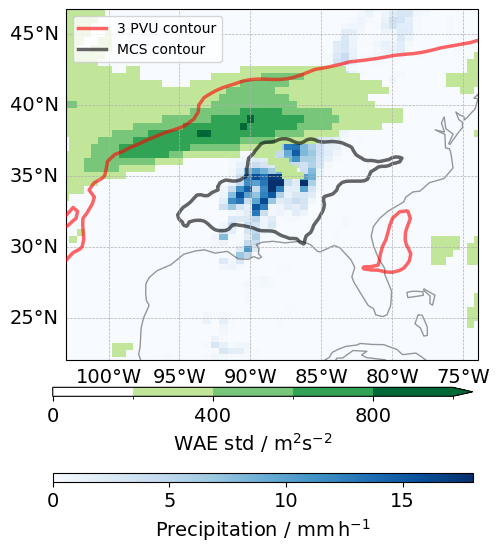

In [15]:
plot_WAE_irr_wind(
    times=pd.to_datetime(["2020-02-11T18"]),
    dataset_list=[("ICON 10km", ds_R02B08)],
    surface_list=[ds_R02B08_surf])

### Correlation

In [20]:
time_error ='2020-02-12T15:00'
lat_min, lat_max = 40, 55
lon_min, lon_max = -70, -50

In [21]:
PV_all = {}
WAE_all = {}
acc_all = {}

# Pattern dictionary
path_patterns = {
    "R02B07": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_*_out6_concat_ERA.nc",
    "R02B08": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B08/Ensembles_IC_perturb/Dennis_ensemble_R02B08_IC_*_out6_concat_ERA.nc",
    "R02B08_no_conv": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B08_no_conv/Ensembles_IC_perturb/Dennis_ensemble_R02B08_no_conv_IC_*_out6_concat_ERA.nc",
    "R02B09": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B09/Ensembles_IC_perturb/Dennis_ensemble_R02B09_IC_*_out6_concat_ERA.nc",
    "R02B10": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B10/Ensembles_IC_perturb/Dennis_ensemble_R02B10_IC_*_out6_concat_ERA.nc",
}

# Regex to extract ensemble numbers
ens_regex = re.compile(r".*_(\d{3})_out6_concat_ERA\.nc$")

for model, pattern in path_patterns.items():
    print(f"\n=== Processing model: {model} ===")

    # Identify available files
    files = sorted(glob.glob(pattern))
    print(f"Found {len(files)} ensemble files.")

    PV_list = []
    WAE_list = []

    # Compute ACC values
    names_acc, acc_vals = compute_acc_members(pattern, z500_era, ERA5_30D_mean_climatology)
    acc_all[model] = np.array(acc_vals, dtype=float)

    for f in files:
        print(f"Opening: {f}")

        try:
            ds = xr.open_dataset(f)
        except Exception as e:
            print(f"  -> Failed to open: {e}")
            PV_list.append(np.nan)
            WAE_list.append(np.nan)
            continue

        # Compute WAE
        E = compute_wave_error(time_error, ds_era_wind, ds)
        WAE_mean = (
            E.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
             .mean()
             .values
        )

        # PV at 250 hPa
        pv_field = (
            ds.pv.sel(plev=25000)
                .sel(time=time_error)
                .sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
                .load() / 1e-6
        )

        # latitude weights for area weighting
        weights = np.cos(np.deg2rad(pv_field.lat))

        PV_val = pv_field.mean().values

        PV_list.append(PV_val)
        WAE_list.append(WAE_mean)

    PV_all[model] = np.array(PV_list, dtype=float)
    WAE_all[model] = np.array(WAE_list, dtype=float)


=== Processing model: R02B07 ===
Found 50 ensemble files.
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_000_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_001_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_002_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_003_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_004_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_005_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_006_out6_concat_ERA.nc
Opening: /

In [22]:
data = {
    "20 km": {"PV": PV_all["R02B07"], "WAE": WAE_all["R02B07"], "ACC": acc_all["R02B07"],"color": "darkorange"},
    "10 km": {"PV": PV_all["R02B08"], "WAE": WAE_all["R02B08"], "ACC": acc_all["R02B08"], "color": "forestgreen"},
    "10 km\nconv. off": {"PV": PV_all["R02B08_no_conv"], "WAE": WAE_all["R02B08_no_conv"], "ACC": acc_all["R02B08_no_conv"], "color": "#8da0cb"},
    "5 km": {"PV": PV_all["R02B09"], "WAE": WAE_all["R02B09"], "ACC": acc_all["R02B09"], "color": "mediumblue"},
    "2.5 km": {"PV": PV_all["R02B10"], "WAE": WAE_all["R02B10"], "ACC": acc_all["R02B10"], "color": "firebrick"},
}

In [23]:
pv_era = xr.open_dataset('/net/thermo/atmosdyn2/era5/isen/2020/02/T20200212_15')
pv_era_250 = pv_era.PV.sel(dimx_PV=slice(lat_min, lat_max), dimy_PV=slice(lon_min, lon_max)).sel(dimz_PV = 3).mean().values

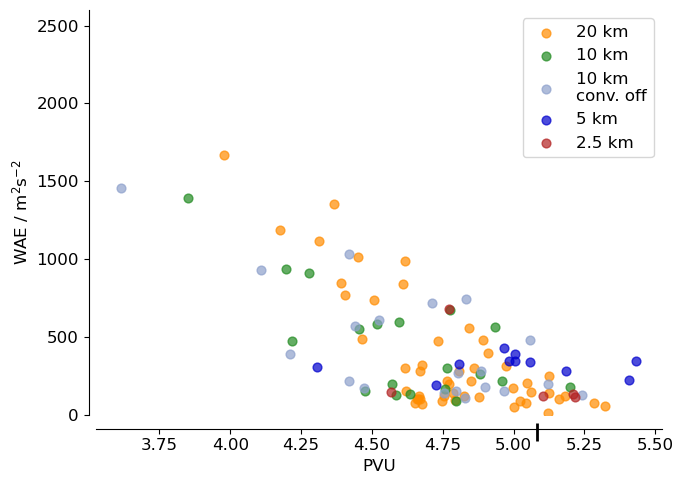

correlation is r = -0.68, and p value p = 1.7e-15


In [24]:
fig, ax = plt.subplots(figsize=(7,5))

# ----------------------------------------
# Collect all models together for a global correlation
PV_all_res = []
WAE_all_res = []
# ----------------------------------------

for label, d in data.items():

    PV = np.array(d["PV"], dtype=float) 
    WAE = np.array(d["WAE"], dtype=float)

    # Remove NaNs
    mask = ~np.isnan(PV) & ~np.isnan(WAE)
    PV_clean = PV[mask]
    WAE_clean = WAE[mask]

    # Add to global arrays
    PV_all_res.append(PV_clean)
    WAE_all_res.append(WAE_clean)

    # Plot each resolution
    ax.scatter(
        PV_clean, WAE_clean,
        color=d["color"],
        label=label,
        s=40,
        alpha=0.7
    )

# ---- Global correlation across resolutions ----
PV_flat = np.concatenate(PV_all_res)
WAE_flat = np.concatenate(WAE_all_res)

r, p = pearsonr(PV_flat, WAE_flat)

ax.set_xlabel(r"PVU")
ax.set_ylabel(r"WAE / $\rm m^2s^{-2}$")
#ax.set_title(f"r = {r:.2f}, p = {p:.1e}")


ax.vlines(
    pv_era_250,
    ymin=ax.get_ylim()[0]- 100,    # or a small offset like -0.01
    ymax=ax.get_ylim()[0] + 0.01 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 
    color="black",
    linewidth=2,
    clip_on=False
)

ax.set_ylim(0,2600)
ax.legend(frameon=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_position(("outward", 10))
ax.spines["left"].set_position(("outward", 5))
plt.tight_layout()
plt.savefig("../Figures/Dennis_correlation_WAE_PVU.pdf", dpi=300, bbox_inches="tight")
plt.show()
print(f'correlation is r = {r:.2f}, and p value p = {p:.1e}')

In [25]:
time_error ='2020-02-14T00:00'
lat_min, lat_max = 45, 60
lon_min, lon_max = -40, -5

In [26]:
PV_all = {}
WAE_all = {}
acc_all = {}

# Pattern dictionary
path_patterns = {
    "R02B07": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_*_out6_concat_ERA.nc",
    "R02B08": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B08/Ensembles_IC_perturb/Dennis_ensemble_R02B08_IC_*_out6_concat_ERA.nc",
    "R02B08_no_conv": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B08_no_conv/Ensembles_IC_perturb/Dennis_ensemble_R02B08_no_conv_IC_*_out6_concat_ERA.nc",
    "R02B09": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B09/Ensembles_IC_perturb/Dennis_ensemble_R02B09_IC_*_out6_concat_ERA.nc",
    "R02B10": "/highres_nobackup/mrixen/simulations/Dennis_v1/R02B10/Ensembles_IC_perturb/Dennis_ensemble_R02B10_IC_*_out6_concat_ERA.nc",
}

# Regex to extract ensemble numbers
ens_regex = re.compile(r".*_(\d{3})_out6_concat_ERA\.nc$")

for model, pattern in path_patterns.items():
    print(f"\n=== Processing model: {model} ===")

    # Identify available files
    files = sorted(glob.glob(pattern))
    print(f"Found {len(files)} ensemble files.")

    PV_list = []
    WAE_list = []

    # Compute ACC values
    names_acc, acc_vals = compute_acc_members(pattern, z500_era, ERA5_30D_mean_climatology)
    acc_all[model] = np.array(acc_vals, dtype=float)

    for f in files:
        print(f"Opening: {f}")

        try:
            ds = xr.open_dataset(f)
        except Exception as e:
            print(f"  -> Failed to open: {e}")
            PV_list.append(np.nan)
            WAE_list.append(np.nan)
            continue

        # Compute WAE
        E = compute_wave_error(time_error, ds_era_wind, ds)
        WAE_mean = (
            E.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
             .mean()
             .values
        )

        # PV at 250 hPa
        u = ds.u.sel(plev=25000).sel(time=time_error)
        v = ds.v.sel(plev=25000).sel(time=time_error)

        u_ = u.values   # shape (lat, lon)
        v_ = v.values
        lat = np.deg2rad(u.lat.values)  # 1D
        lon = np.deg2rad(u.lon.values)  # 1D

        Re = 6371000.0  # Earth radius (m)

        # --- Compute grid spacing ---
        dlat = np.gradient(lat)                      # 1D (lat)
        dlon = np.gradient(lon)                      # 1D (lon)

        # Expand to 2D spacing arrays
        dy = Re * dlat[:, None]                      # shape (lat, lon)
        dx = Re * np.cos(lat)[:, None] * dlon[None,:]

        # --- Compute derivatives ---
        dv_dx = np.gradient(v_, axis=1) / dx         # ∂v/∂x
        du_dy = np.gradient(u_, axis=0) / dy         # ∂u/∂y

        # --- Relative vorticity ζ ---
        vort = dv_dx - du_dy                         # 2D array (lat, lon)

        # --- Regional mean ---
        vort_da = xr.DataArray(
            vort,
            coords=u.coords,
            dims=u.dims
        ).sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # latitude weights for spherical area weighting
        weights = np.cos(np.deg2rad(vort_da.lat))

        vort_val = vort_da.weighted(weights).mean().values

        PV_list.append(float(vort_val))
        WAE_list.append(WAE_mean)

    PV_all[model] = np.array(PV_list, dtype=float)
    WAE_all[model] = np.array(WAE_list, dtype=float)



=== Processing model: R02B07 ===
Found 50 ensemble files.
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_000_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_001_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_002_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_003_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_004_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_005_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_006_out6_concat_ERA.nc
Opening: /

Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_023_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_024_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_025_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_026_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_027_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_028_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensembles_IC_perturb/Dennis_ensemble_R02B07_IC_029_out6_concat_ERA.nc
Opening: /highres_nobackup/mrixen/simulations/Dennis_v1/R02B07/Ensemb

In [27]:
data = {
    "20 km": {"PV": PV_all["R02B07"], "WAE": WAE_all["R02B07"], "ACC": acc_all["R02B07"],"color": "darkorange"},
    "10 km": {"PV": PV_all["R02B08"], "WAE": WAE_all["R02B08"], "ACC": acc_all["R02B08"], "color": "forestgreen"},
    "10 km\nconv. off": {"PV": PV_all["R02B08_no_conv"], "WAE": WAE_all["R02B08_no_conv"], "ACC": acc_all["R02B08_no_conv"], "color": "#8da0cb"},
    "5 km": {"PV": PV_all["R02B09"], "WAE": WAE_all["R02B09"], "ACC": acc_all["R02B09"], "color": "mediumblue"},
    "2.5 km": {"PV": PV_all["R02B10"], "WAE": WAE_all["R02B10"], "ACC": acc_all["R02B10"], "color": "firebrick"},
}

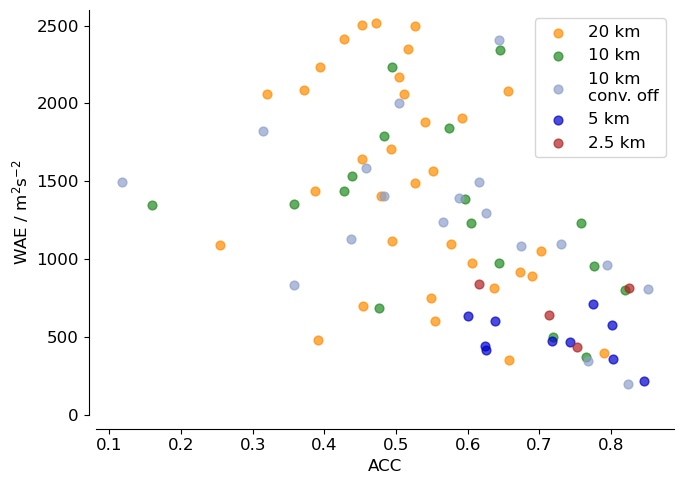

correlation is r = -0.65, and p value p = 8.5e-14


In [28]:
fig, ax = plt.subplots(figsize=(7,5))

# ----------------------------------------
# Collect all models together for a global correlation
ACC_all_res = []
WAE_all_res = []
# ----------------------------------------

for label, d in data.items():

    ACC = np.array(d["ACC"], dtype=float)
    WAE = np.array(d["WAE"], dtype=float)

    # Remove NaNs
    mask = ~np.isnan(ACC) & ~np.isnan(WAE)
    ACC_clean = ACC[mask]
    WAE_clean = WAE[mask]

    # Collect for global correlation
    ACC_all_res.append(ACC_clean)
    WAE_all_res.append(WAE_clean)

    # Plot each resolution
    ax.scatter(
        ACC_clean, WAE_clean,
        color=d["color"],
        label=label,
        s=40,
        alpha=0.7
    )

# ---- Global correlation across all resolutions ----
ACC_flat = np.concatenate(ACC_all_res)
WAE_flat = np.concatenate(WAE_all_res)

r, p = pearsonr(ACC_flat, WAE_flat)

ax.set_xlabel("ACC")
ax.set_ylabel(r"WAE / $\rm m^2s^{-2}$")

ax.set_ylim(0, 2600)

ax.legend(frameon=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_position(("outward", 10))
ax.spines["left"].set_position(("outward", 5))

plt.tight_layout()
plt.savefig("../Figures/Dennis_correlation_WAE_ACC.pdf", dpi=300, bbox_inches="tight")

plt.show()
print(f'correlation is r = {r:.2f}, and p value p = {p:.1e}')

## MCS

In [4]:
ds_era_pv= load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='S',
)

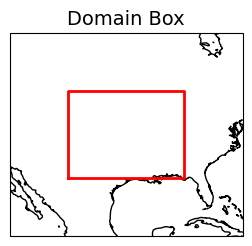

In [5]:
lat_min = 30
lat_max = 45
lon_min = -105
lon_max = -85

fig = plt.figure(figsize=(3,4))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
ax.coastlines()
ax.plot([lon_min, lon_max, lon_max, lon_min, lon_min],[lat_min, lat_min, lat_max, lat_max, lat_min],transform=ccrs.PlateCarree(),color='red',linewidth=2)

plt.title("Domain Box")
plt.show()

In [6]:
pv_era = xr.open_dataset('/net/thermo/atmosdyn2/era5/isen/2020/02/T20200211_15')
pv_era_250_MCS = pv_era.PV
pv_era_fixed = pv_era_250_MCS.rename({
    "dimy_PV": "lat",
    "dimx_PV": "lon"
})
pv_era_fixed = pv_era_fixed.assign_coords(
    lat = pv_era_fixed.lat.values,
    lon = pv_era_fixed.lon.values
)

In [32]:
def compute_all_ensembles(ds, threshold_pv):
    """
    Apply compute_MCS_intensity_pv to every ensemble member
    in a dataset that has an 'ensemble' dimension.

    Returns a NumPy array of shape (n_ensemble,)
    """
    ens_values = ds.ensemble.values
    results = []

    for e in ens_values:
        area = compute_MCS_intensity_pv(
            ds.sel(ensemble=e),
            threshold_pv,
            lat_min, lat_max, lon_min, lon_max
        )
        results.append(area)

    return np.array(results)

In [33]:
MCS_area_pv = {}  # container for results

time_pv = "2020-02-11T18:00"
threshold_pv = 0

for res, ds in ds_dict.items():
    print(f"➡️ Computing MCS PV area for {res} ...")
    
    MCS_area_pv[res] = compute_all_ensembles(
        ds.pv.sel(time=time_pv, plev=25000)/1e-6,
        threshold_pv=threshold_pv
    )
    
    print(f"✔ Done: shape = {MCS_area_pv[res].shape}")

➡️ Computing MCS PV area for R02B07 ...


✔ Done: shape = (50,)
➡️ Computing MCS PV area for R02B08 ...
✔ Done: shape = (20,)
➡️ Computing MCS PV area for R02B08_no_conv ...
✔ Done: shape = (20,)
➡️ Computing MCS PV area for R02B09 ...
✔ Done: shape = (11,)
➡️ Computing MCS PV area for R02B10 ...
✔ Done: shape = (5,)


In [34]:
mean_PV_250 = xr.open_dataset('/highres_nobackup/mrixen/ERA5/PV_upper_level_clima/mean_PV_250_JFM')
mean_PV_250 = mean_PV_250.sel(lev=250).mean(dim='time').PV

#computation of negative PV anomaly area for ERA
pv_era_250_MCS_US = xr.open_dataset('/highres_nobackup/mrixen/ERA5/PV_upper_level_clima/PV_250_Dennis')
era5_area_MCS = compute_MCS_intensity_pv(pv_era_250_MCS_US.PV.sel(time=22, lev=250), threshold_pv, lat_min, lat_max, lon_min, lon_max)

# computation of negative PV anomaly area for IFS
pv_ifs_250_MCS_US = xr.open_dataset('/highres_nobackup/mrixen/simulations/Dennis_v1/IFS_data/IFS_forecast_pv_250.nc')
pv_ifs_250_MCS_US = pv_ifs_250_MCS_US.rename({'latitude': 'lat', 'longitude': 'lon'})
pv_ifs_250_MCS_US = pv_ifs_250_MCS_US.sel(lat=pv_ifs_250_MCS_US.lat[::-1])
ifs_area_MCS = compute_MCS_intensity_pv(pv_ifs_250_MCS_US.pv.sel(time=time_pv), threshold_pv, lat_min, lat_max, lon_min, lon_max)

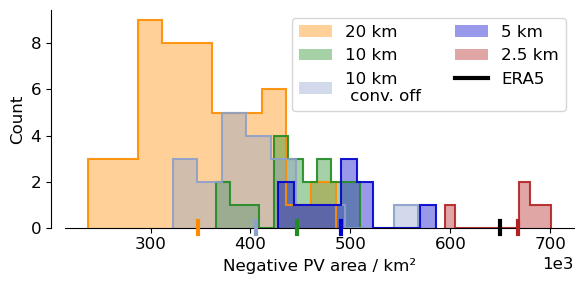

In [35]:
import matplotlib.patheffects as pe

plt.figure(figsize=(6,3))

# Your color dictionary

labels = {
    "R02B07": "20 km",
    "R02B08": "10 km",
    "R02B08_no_conv": "10 km \n conv. off",
    "R02B09": "5 km",
    "R02B10": "2.5 km"
}

colors = {
    "R02B07": "darkorange",
    "R02B08": "forestgreen",
    "R02B08_no_conv": "#8da0cb",
    "R02B09": "mediumblue",
    "R02B10": "firebrick"
}

#bins = np.linspace(2e5, 1.4e6, 30)

# Plot histogram for each resolution
for res, arr in MCS_area_pv.items():
    plt.hist(arr, alpha=0.4, label=labels[res], color=colors[res])

for res, arr in MCS_area_pv.items():
    plt.hist(arr, histtype='step', linewidth=1.5, color=colors[res], alpha = 0.9)

# Add vertical colored ticks for the mean of each distribution
for res, arr in MCS_area_pv.items():
    mean_val = np.nanmean(arr)
    plt.axvline(
        mean_val,
        ymin=-0.03, ymax=0.03,
        color=colors[res],
        linewidth=3,
        clip_on=False,
        alpha=1,
        zorder=5
    )

plt.axvline(
    era5_area_MCS,
    ymin=-0.03, ymax=0.03,
    color='k',
    linewidth=3,
    clip_on=False,
    alpha=1,
    zorder=5,
    label='ERA5' 
)

line = plt.axvline(
    ifs_area_MCS,
    ymin=-0.02, ymax=0.02,
    color='magenta',
    linewidth=3,
    clip_on=False,
    alpha=0,
    zorder=5,
    #label='IFS' 
)

plt.xlabel("Negative PV area / km²")
plt.ylabel("Count")
plt.title("")
plt.legend(ncols = 2)
#plt.ylim(0.05,11)
# Adjust spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move bottom & left spines outward
ax.spines["left"].set_position(("outward", 10))
ax.ticklabel_format(axis='x', style='sci', scilimits=(3,3))
#ax.xaxis.get_offset_text().set_x(1.02)

plt.tight_layout()
plt.savefig(
    "../Figures/Dennis_neg_PV_anomaly_area.pdf", 
    dpi=300, 
    bbox_inches="tight"
)
plt.show()

## Precipitation

In [4]:
base_path = "/highres_nobackup/mrixen/simulations/Dennis_v1"

# === Define resolutions and folder names ===
resolutions = {
    "R02B06": "R02B06/Ensembles_IC_perturb",
    "R02B07": "R02B07/Ensembles_IC_perturb",
    "R02B08": "R02B08/Ensembles_IC_perturb",
    "R02B08_no_conv": "R02B08_no_conv/Ensembles_IC_perturb",
    "R02B09": "R02B09/Ensembles_IC_perturb",
    "R02B10": "R02B10/Ensembles_IC_perturb"
}

# === Container for all datasets ===
ds_dict = {}

# === Loop through resolutions ===
for res, subdir in resolutions.items():
    path = f"{base_path}/{subdir}"

    # 1️⃣ Find all matching ensemble files
    files = sorted(glob.glob(f"{path}/Dennis_ensemble_{res}_IC_???_out1_concat_ERA.nc"))
    if not files:
        print(f"⚠️ No files found for {res}")
        continue

    # 2️⃣ Extract ensemble IDs
    ensemble_ids = [int(re.search(r'_IC_(\d+)_', f).group(1)) for f in files]

    # 3️⃣ Open lazily and in parallel
    print(f"📂 Opening {len(files)} files for {res} ...")
    ds = xr.open_mfdataset(
        files,
        concat_dim="ensemble",
        combine="nested",
        parallel=True,
        engine="netcdf4",
        chunks={"time": 50}
    )

    # 4️⃣ Assign ensemble coordinate
    ds = ds.assign_coords(ensemble=("ensemble", ensemble_ids))

    # 5️⃣ Store dataset in dictionary
    ds_dict[res] = ds
    print(f"✅ Loaded {res} with shape {dict(ds.dims)}")

# === Example access ===
ds_R02B06_surf = ds_dict["R02B06"]
ds_R02B07_surf = ds_dict["R02B07"]
ds_R02B08_surf = ds_dict["R02B08"]
ds_R02B08_no_conv_surf = ds_dict["R02B08_no_conv"]
ds_R02B09_surf = ds_dict["R02B09"]
ds_R02B10_surf = ds_dict["R02B10"]

📂 Opening 50 files for R02B06 ...
✅ Loaded R02B06 with shape {'ensemble': 50, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 49 files for R02B07 ...
✅ Loaded R02B07 with shape {'ensemble': 49, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 17 files for R02B08 ...
✅ Loaded R02B08 with shape {'ensemble': 17, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08_no_conv ...
✅ Loaded R02B08_no_conv with shape {'ensemble': 20, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 11 files for R02B09 ...
✅ Loaded R02B09 with shape {'ensemble': 11, 'time': 289, 'lat': 361, 'lon': 720}
📂 Opening 4 files for R02B10 ...
✅ Loaded R02B10 with shape {'ensemble': 4, 'time': 289, 'lat': 361, 'lon': 720}


In [9]:
lat_min = 25
lat_max = 50
lon_min = -105
lon_max = -75
time_MCS_start = '2020-02-10T00:00'
time_MCS_end   = '2020-02-12T00:00'

In [10]:
start_era = '2020-02-08T00'
end_era = '2020-02-13T00'
ds_era_surf= load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='N',
    freq='1H'
)
ds_era_surf_precip = ds_era_surf['LSP'] + ds_era_surf['CP'] 

### Get IMERG data

In [11]:
#base_path = "/highres_nobackup/observations/GPM_IMERG_V07/2020"
base_path = "/highres_nobackup/mrixen/simulations/Dennis_v1/observations/IMERG/ERA_grid"

# Select files from 20200210 to 20200212
files = sorted(
    glob.glob(os.path.join(base_path, "3B-HHR.MS.MRG.3IMERG.2020021*.nc"))
)

# Keep only the desired dates explicitly (safer)
files = [
    f for f in files
    if any(date in f for date in ["20200210", "20200211", "20200212"])
]

print(f"Found {len(files)} files")

# Open all and concatenate along time
IMERG_all = xr.open_mfdataset(
    files,
    combine="by_coords",
    parallel=True
)

times = pd.date_range("2020-02-10 00:00", "2020-02-12 23:00", freq="1H")

files = []
for t in times:
    stamp = t.strftime("%Y%m%d-S%H0000")
    pattern = f"{base_path}/3B-HHR.MS.MRG.3IMERG.{stamp}*.HDF5"
    matches = glob.glob(pattern)
    files.extend(matches)

files = sorted(files)

Found 144 files


### Plotting

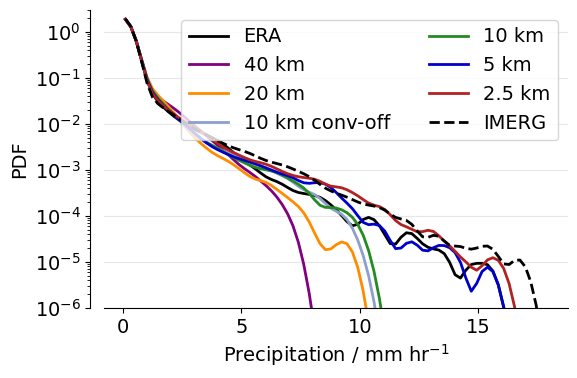

In [12]:
datasets = {
    "ERA": ds_era_surf_precip * 1000.0,
    "40 km": ds_R02B06_surf,
    "20 km": ds_R02B07_surf,
    "10 km conv-off": ds_R02B08_no_conv_surf,
    "10 km": ds_R02B08_surf,
    "5 km": ds_R02B09_surf,
    "2.5 km": ds_R02B10_surf,
}

colors = {
    "40 km": "purple",          # R02B06
    "20 km": "darkorange",          # R02B07
    "10 km": "forestgreen",         # R02B08
    "10 km conv-off": "#8da0cb",    # R02B08_no_conv
    "5 km": "mediumblue",           # R02B09
    "2.5 km": "firebrick",           # R02B10
    "ERA": "k"
}


plt.figure(figsize=(6,4))
bins = np.linspace(0, 18, 80)
# --- 1) Plot ICON / ERA datasets ---
for label, ds in datasets.items():

    # Select domain and time
    if label == "ERA":
        ds_sel = ds.sel(
            lat=slice(lat_min, lat_max),
            lon=slice(lon_min, lon_max),
            time=slice(time_MCS_start, time_MCS_end),
        )
        precip_mean = ds_sel

    else:
        ds_sel = ds.sel(
            lat=slice(lat_min, lat_max),
            lon=slice(lon_min, lon_max),
            time=slice(time_MCS_start, time_MCS_end)
        )
        precip = ds_sel["tot_prec"]
        precip_mean = precip.mean(dim="ensemble")

    # Flatten to 1D
    arr = precip_mean.values.ravel()
    arr = arr[np.isfinite(arr)]

    # Histogram PDF
    hist, edges = np.histogram(arr, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Smooth and plot
    hist_smooth = gaussian_filter1d(hist, sigma=1.5)

    color = "black" if label == "ERA" else colors[label]
    plt.plot(centers, hist_smooth, lw=2, color=color, label=label)

# --- 2) Add IMERG ---
ds_sel = IMERG_all.sel(
    time=slice(time_MCS_start, time_MCS_end),
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max),
)

precip = ds_sel["precipitation"]
arr = precip.values.ravel()
arr = arr[np.isfinite(arr)]


hist, edges = np.histogram(arr, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
hist_smooth = gaussian_filter1d(hist, sigma=1.5)

plt.plot(centers, hist_smooth, lw=2, color="black", linestyle="--", label="IMERG")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_position(("outward", 10))

# --- Figure formatting ---
plt.ylim(1e-6, 3)
#plt.xlim(0,18)
plt.yscale("log")
plt.xlabel("Precipitation / mm hr$^{-1}$")
plt.ylabel("PDF")
plt.grid(True, axis="y", alpha=0.3)
plt.legend(ncols = 2)
plt.tight_layout()
plt.savefig("../Figures/Dennis_precip_MCS_all.pdf", dpi=300, bbox_inches="tight")
plt.show()